# RobustOps Master v2 — Patched
4x stronger drift, ResNet 25 epochs, real FGSM for ASR, MLP-based Mitigation 2b, rescaled risk ablation. Outputs to outputs_v2/.

## Setup

In [1]:
!pip -q install torch torchvision transformers datasets xgboost scikit-learn matplotlib pandas numpy


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import os,json,random,zipfile
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import DataLoader
ROOT='/workspace/robustops'
CKPT=f'{ROOT}/checkpoints_v2'; DATA=f'{ROOT}/data'; OUT=f'{ROOT}/outputs_v2'
for d in [CKPT,DATA,OUT]: os.makedirs(d,exist_ok=True)
SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE='cuda'; NW=8
print('device',torch.cuda.get_device_name(0))
ALL={}

device NVIDIA GeForce RTX 4090


## Task 1a — ResNet-18 CIFAR-10 (25 epochs)

In [3]:
import torchvision
from torchvision import transforms
from torchvision.models import resnet18
MEAN=(0.4914,0.4822,0.4465); STD=(0.247,0.2435,0.2616)
tr_t=transforms.Compose([transforms.RandomCrop(32,padding=4),transforms.RandomHorizontalFlip(),transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
te_t=transforms.Compose([transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
ctr=torchvision.datasets.CIFAR10(DATA,train=True,download=True,transform=tr_t)
cte=torchvision.datasets.CIFAR10(DATA,train=False,download=True,transform=te_t)
trl=DataLoader(ctr,batch_size=512,shuffle=True,num_workers=NW,pin_memory=True,persistent_workers=True)
tel=DataLoader(cte,batch_size=1024,shuffle=False,num_workers=NW,pin_memory=True)
resnet=resnet18(num_classes=10).to(DEVICE)
opt=torch.optim.SGD(resnet.parameters(),lr=0.1,momentum=0.9,weight_decay=5e-4,nesterov=True)
EP=25
sch=torch.optim.lr_scheduler.OneCycleLR(opt,max_lr=0.4,epochs=EP,steps_per_epoch=len(trl))
sc=GradScaler()
for e in range(EP):
    resnet.train()
    for x,y in trl:
        x,y=x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with autocast(): loss=F.cross_entropy(resnet(x),y)
        sc.scale(loss).backward(); sc.step(opt); sc.update(); sch.step()
    if (e+1)%5==0: print(f'cifar ep {e+1}/{EP}')
resnet.eval(); cc=t=0
with torch.no_grad():
    for x,y in tel:
        x,y=x.to(DEVICE),y.to(DEVICE)
        cc+=(resnet(x).argmax(1)==y).sum().item(); t+=y.size(0)
cifar_acc=cc/t; print('resnet acc',cifar_acc)
torch.save(resnet.state_dict(),f'{CKPT}/resnet18.pt')
ALL['resnet_acc']=cifar_acc

Files already downloaded and verified


/usr/local/lib/python3.11/dist-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified


/tmp/ipykernel_3379/2165854556.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  sc=GradScaler()
/tmp/ipykernel_3379/2165854556.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): loss=F.cross_entropy(resnet(x),y)


cifar ep 5/25
cifar ep 10/25
cifar ep 15/25
cifar ep 20/25
cifar ep 25/25
resnet acc 0.8555


## Task 1b — DistilBERT SST-2

In [4]:
from datasets import load_dataset
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
sst=load_dataset('glue','sst2')
tok=DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
def enc(b): return tok(b['sentence'],truncation=True,padding='max_length',max_length=128)
sste=sst.map(enc,batched=True); sste.set_format('torch',columns=['input_ids','attention_mask','label'])
distil=DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased',num_labels=2).to(DEVICE)
op=torch.optim.AdamW(distil.parameters(),lr=3e-5)
tdl=DataLoader(sste['train'],batch_size=64,shuffle=True,num_workers=NW,pin_memory=True)
vdl=DataLoader(sste['validation'],batch_size=128,num_workers=NW)
sc2=GradScaler(); distil.train()
for step,b in enumerate(tdl):
    b={k:v.to(DEVICE,non_blocking=True) for k,v in b.items()}
    op.zero_grad(set_to_none=True)
    with autocast(): o=distil(input_ids=b['input_ids'],attention_mask=b['attention_mask'],labels=b['label'])
    sc2.scale(o.loss).backward(); sc2.step(op); sc2.update()
    if step>=1500: break
distil.eval(); cc=t=0
with torch.no_grad():
    for b in vdl:
        b={k:v.to(DEVICE) for k,v in b.items()}
        p=distil(input_ids=b['input_ids'],attention_mask=b['attention_mask']).logits.argmax(1)
        cc+=(p==b['label']).sum().item(); t+=b['label'].size(0)
sst_acc=cc/t; print('distil acc',sst_acc)
distil.save_pretrained(f'{CKPT}/distilbert'); tok.save_pretrained(f'{CKPT}/distilbert')
ALL['distil_acc']=sst_acc

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_3379/3954481204.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  sc2=GradScaler(); distil.train()
/tmp/ipykernel_3379/3954481204.py:

distil acc 0.9048165137614679


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## Task 1c — XGBoost Adult + CalHousing

In [5]:
import xgboost as xgb
from sklearn.datasets import fetch_openml, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, r2_score
ad=fetch_openml('adult',version=2,as_frame=True)
Xa=pd.get_dummies(ad.data,drop_first=True).astype(float)
ya=(ad.target=='>50K').astype(int).values
Xatr,Xate,yatr,yate=train_test_split(Xa.values,ya,test_size=0.2,random_state=SEED,stratify=ya)
sa=StandardScaler().fit(Xatr); Xatr=sa.transform(Xatr); Xate=sa.transform(Xate)
xcls=xgb.XGBClassifier(n_estimators=300,max_depth=6,learning_rate=0.1,tree_method='hist',device='cuda',random_state=SEED)
xcls.fit(Xatr,yatr); aa=accuracy_score(yate,xcls.predict(Xate)); print('adult',aa)
xcls.save_model(f'{CKPT}/xgb_adult.json')
np.savez(f'{DATA}/adult_splits.npz',Xtr=Xatr,Xte=Xate,ytr=yatr,yte=yate)
cal=fetch_california_housing()
Xctr,Xcte,yctr,ycte=train_test_split(cal.data,cal.target,test_size=0.2,random_state=SEED)
scal=StandardScaler().fit(Xctr); Xctr=scal.transform(Xctr); Xcte=scal.transform(Xcte)
xreg=xgb.XGBRegressor(n_estimators=300,max_depth=6,learning_rate=0.1,tree_method='hist',device='cuda',random_state=SEED)
xreg.fit(Xctr,yctr); cr=r2_score(ycte,xreg.predict(Xcte)); print('cal r2',cr)
xreg.save_model(f'{CKPT}/xgb_cal.json')
np.savez(f'{DATA}/calhousing_splits.npz',Xtr=Xctr,Xte=Xcte,ytr=yctr,yte=ycte)
ALL['adult_acc']=aa; ALL['cal_r2']=cr

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:751: UserWarning: [01:18:18] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


adult 0.8775719111475074
cal r2 0.8408715984779023


## Task 1d — Diagnosis primitives + FGSM helpers

In [6]:
def mmd(X,Y,s=1.0):
    X=np.asarray(X,np.float32); Y=np.asarray(Y,np.float32)
    if X.ndim>2: X=X.reshape(len(X),-1)
    if Y.ndim>2: Y=Y.reshape(len(Y),-1)
    n=min(len(X),len(Y),500); X=X[:n]; Y=Y[:n]
    def k(A,B): return np.exp(-((A[:,None,:]-B[None,:,:])**2).sum(-1)/(2*s*s))
    return float(k(X,X).mean()+k(Y,Y).mean()-2*k(X,Y).mean())
def jsd(a,b,K):
    pa=np.bincount(a,minlength=K).astype(float)+1e-6; pa/=pa.sum()
    pb=np.bincount(b,minlength=K).astype(float)+1e-6; pb/=pb.sum()
    m=0.5*(pa+pb)
    return float(0.5*(pa*np.log(pa/m)).sum()+0.5*(pb*np.log(pb/m)).sum())
def classify(px,pyx,py,tau=0.01):
    if max(px,pyx,py)<tau: return 'none'
    if pyx>1.2*max(px,py): return 'concept'
    if py>1.2*px: return 'label'
    if px>=max(pyx,py): return 'covariate'
    return 'mixed'
def fgsm_image(model,x,y,eps=8/255):
    x=x.clone().detach().requires_grad_(True)
    loss=F.cross_entropy(model(x),y)
    loss.backward()
    return (x+eps*x.grad.sign()).detach()
DRIFTS=[('drift1',1.2,False),('drift2',2.0,False),('drift3',3.2,True)]
DIAG=[]

## Task 1e — Stronger drift injection + diagnosis

In [12]:
def diag_tab(name,mdl,Xte,yte,is_reg):
    rng=np.random.RandomState(SEED)
    bi=rng.choice(len(Xte),500,replace=False); Xb,yb=Xte[bi],yte[bi]; pb=mdl.predict(Xb)
    for dn,sg,rb in DRIFTS:
        Xd=Xte+rng.randn(*Xte.shape)*sg
        if is_reg:
            yd=yte + 0.4*Xd[:,0]*Xd[:,3] + 0.3*np.sin(Xd[:,1]*sg)
        else:
            yd=yte.copy()
            if rb:
                f=rng.rand(len(yd))<0.15; yd[f]=1-yd[f]
        idx=rng.choice(len(Xd),500,replace=False); Xw,yw=Xd[idx],yd[idx]; pw=mdl.predict(Xw)
        px=mmd(Xb,Xw,1.0)
        if is_reg:
            pyx=float(abs(pw.mean()-pb.mean())/(pb.std()+1e-6) + abs(pw.std()-pb.std())/(pb.std()+1e-6))
            py=float(abs(yw.mean()-yb.mean())/(yb.std()+1e-6))
        else:
            K=int(max(pb.max(),pw.max()))+1
            pyx=jsd(pb.astype(int),pw.astype(int),K)
            py=jsd(yb.astype(int),yw.astype(int),int(max(yb.max(),yw.max()))+1)
        sh=classify(px,pyx,py)
        DIAG.append({'modality':name,'drift':dn,'P(X)':px,'P(Y|X)':pyx,'P(Y)':py,'diagnosis':sh})
        print(f'{name} {dn}: PX={px:.4f} PYX={pyx:.4f} PY={py:.4f} -> {sh}')
DIAG=[]
ad_d=np.load(f'{DATA}/adult_splits.npz'); diag_tab('tab_cls',xcls,ad_d['Xte'],ad_d['yte'],False)
ca_d=np.load(f'{DATA}/calhousing_splits.npz'); diag_tab('tab_reg',xreg,ca_d['Xte'],ca_d['yte'],True)

def diag_img():
    resnet.eval()
    X=[]; Y=[]
    for x,y in tel:
        X.append(x.numpy()); Y.append(y.numpy())
    X=np.concatenate(X); Y=np.concatenate(Y)
    rng=np.random.RandomState(SEED); bi=rng.choice(len(X),500,replace=False)
    Xb=X[bi]; Yb=Y[bi]
    with torch.no_grad(): Pb=resnet(torch.tensor(Xb).to(DEVICE)).argmax(1).cpu().numpy()
    img_sigmas={'drift1':0.15,'drift2':0.3,'drift3':0.5}
    for dn,sg,rb in DRIFTS:
        px_sigma=img_sigmas[dn]
        Xd=X+rng.randn(*X.shape).astype(np.float32)*px_sigma
        with torch.no_grad():
            Pd=resnet(torch.tensor(Xd[:2000]).to(DEVICE)).argmax(1).cpu().numpy()
        Yd=Y[:2000].copy()
        if rb:
            f=rng.rand(len(Yd))<0.15; Yd[f]=(Yd[f]+rng.randint(1,10,f.sum()))%10
        idx=rng.choice(2000,500,replace=False)
        Xw,Pw,Yw=Xd[:2000][idx],Pd[idx],Yd[idx]
        px=mmd(Xb.reshape(500,-1)[:,:200],Xw.reshape(500,-1)[:,:200],5.0)
        pyx=jsd(Pb,Pw,10); py=jsd(Yb,Yw,10)
        sh=classify(px,pyx,py)
        DIAG.append({'modality':'image','drift':dn,'P(X)':px,'P(Y|X)':pyx,'P(Y)':py,'diagnosis':sh})
        print(f'image {dn}: PX={px:.4f} PYX={pyx:.4f} PY={py:.4f} -> {sh}')
diag_img()

def diag_nlp():
    distil.eval(); val=sste['validation']
    rng=np.random.RandomState(SEED); N=500
    def embed(ix):
        ids=torch.stack([val[int(i)]['input_ids'] for i in ix]).to(DEVICE)
        am=torch.stack([val[int(i)]['attention_mask'] for i in ix]).to(DEVICE)
        with torch.no_grad():
            emb=distil.distilbert.embeddings(ids).mean(1)
            lg=distil(input_ids=ids,attention_mask=am).logits
        return lg.argmax(1).cpu().numpy(), emb.cpu().numpy()
    bi=rng.choice(len(val),N,replace=False); Pb,Xb=embed(bi)
    Yb=np.array([int(val[int(i)]['label']) for i in bi])
    for dn,sg,rb in DRIFTS:
        wi=rng.choice(len(val),N,replace=False); Pw,Xw=embed(wi)
        Xw=Xw+rng.randn(Xw.shape[1]).astype(np.float32)*sg*0.3
        Yw=np.array([int(val[int(i)]['label']) for i in wi])
        if rb:
            f=rng.rand(len(Yw))<0.15; Yw[f]=1-Yw[f]
        px=mmd(Xb,Xw,5.0); pyx=jsd(Pb,Pw,2); py=jsd(Yb,Yw,2)
        sh=classify(px,pyx,py)
        DIAG.append({'modality':'nlp','drift':dn,'P(X)':px,'P(Y|X)':pyx,'P(Y)':py,'diagnosis':sh})
        print(f'nlp {dn}: PX={px:.4f} PYX={pyx:.4f} PY={py:.4f} -> {sh}')
diag_nlp()
df_diag=pd.DataFrame(DIAG); df_diag.to_csv(f'{OUT}/diagnosis.csv',index=False); print(df_diag)
ALL['diagnosis']=DIAG

tab_cls drift1: PX=0.0048 PYX=0.0016 PY=0.0000 -> none
tab_cls drift2: PX=0.0048 PYX=0.0160 PY=0.0003 -> concept
tab_cls drift3: PX=0.0048 PYX=0.0084 PY=0.0107 -> label
tab_reg drift1: PX=0.0912 PYX=0.9919 PY=0.0488 -> concept
tab_reg drift2: PX=0.1059 PYX=1.0889 PY=0.0796 -> concept
tab_reg drift3: PX=0.1067 PYX=1.2899 PY=0.0330 -> concept
image drift1: PX=0.0056 PYX=0.0020 PY=0.0017 -> none
image drift2: PX=0.0104 PYX=0.0166 PY=0.0043 -> concept
image drift3: PX=0.0259 PYX=0.0664 PY=0.0030 -> concept
nlp drift1: PX=1.6156 PYX=0.0000 PY=0.0000 -> covariate
nlp drift2: PX=1.9026 PYX=0.0000 PY=0.0000 -> covariate
nlp drift3: PX=1.9111 PYX=0.0001 PY=0.0009 -> covariate
   modality   drift      P(X)    P(Y|X)      P(Y)  diagnosis
0   tab_cls  drift1  0.004810  0.001626  0.000048       none
1   tab_cls  drift2  0.004810  0.016001  0.000293    concept
2   tab_cls  drift3  0.004810  0.008424  0.010723      label
3   tab_reg  drift1  0.091245  0.991855  0.048755    concept
4   tab_reg  drift2

## Task 2 — Mitigation Toolbox
2a: replay-CL on regression concept-drift (expect FAIL). 2b: MLP with FGSM adversarial training on pure covariate shift (expect wasted compute + clean-acc degradation).

In [13]:
MIT=[]
d=np.load(f'{DATA}/calhousing_splits.npz')
rng=np.random.RandomState(SEED)
Xtr,ytr,Xte,yte=d['Xtr'],d['ytr'],d['Xte'],d['yte']
Xd=Xte+rng.randn(*Xte.shape)*3.0
yd=yte + 0.4*Xd[:,0]*Xd[:,3] + 0.3*np.sin(Xd[:,1]*3.0)
bi=rng.choice(len(Xtr),500,replace=False)
Xmix=np.concatenate([Xtr[bi],Xd[:125]]); ymix=np.concatenate([ytr[bi],yd[:125]])
m2a=xgb.XGBRegressor(n_estimators=300,max_depth=6,learning_rate=0.1,tree_method='hist',device='cuda',random_state=SEED)
m2a.fit(Xmix,ymix)
r2o=r2_score(yte,m2a.predict(Xte)); r2dr=r2_score(yd,m2a.predict(Xd))
MIT.append({'exp':'2a_replay_on_concept','r2_orig':float(r2o),'r2_drift':float(r2dr),'verdict':'FAIL' if r2dr<0.3 else 'OK'})
print(f'2a: r2_orig={r2o:.4f} r2_drift={r2dr:.4f}')

da=np.load(f'{DATA}/adult_splits.npz')
Xte2=da['Xte'].astype(np.float32); yte2=da['yte']
def acc(mdl,X,y):
    with torch.no_grad():
        p=mdl(torch.tensor(X).to(DEVICE)).argmax(1).cpu().numpy()
    return (p==y).mean()
base_clean=acc(base_mlp,Xte2,yte2); adv_clean=acc(adv_mlp,Xte2,yte2)
Xcov=Xte2+rng.randn(*Xte2.shape).astype(np.float32)*1.5
base_drift=acc(base_mlp,Xcov,yte2); adv_drift=acc(adv_mlp,Xcov,yte2)
MIT.append({'exp':'2b_advtrain_mlp_on_cov','base_clean':float(base_clean),'adv_clean':float(adv_clean),'clean_delta':float(adv_clean-base_clean),'base_drift':float(base_drift),'adv_drift':float(adv_drift)})
print(f'2b MLP: base_clean={base_clean:.4f} adv_clean={adv_clean:.4f} delta={adv_clean-base_clean:+.4f} | base_drift={base_drift:.4f} adv_drift={adv_drift:.4f}')
pd.DataFrame(MIT).to_csv(f'{OUT}/mitigation.csv',index=False)
ALL['mitigation']=MIT

2a: r2_orig=0.6874 r2_drift=0.4353
2b MLP: base_clean=0.8564 adv_clean=0.8523 delta=-0.0041 | base_drift=0.7382 adv_drift=0.7104


## Task 3 — Risk Ablation (rescaled + real FGSM via MLP)

In [14]:
WCFG={'default':(0.35,0.25,0.25,0.15),'equal':(0.25,0.25,0.25,0.25),'acc_dom':(0.6,0.2,0.1,0.1),'adv_dom':(0.1,0.1,0.6,0.2),'conf_dom':(0.1,0.6,0.2,0.1)}
GATE_TAU=0.15
rng=np.random.RandomState(SEED)
def mlp_proba(mdl,X):
    with torch.no_grad():
        return F.softmax(mdl(torch.tensor(X).to(DEVICE)),-1).cpu().numpy()
def fgsm_mlp(mdl,X,y,eps=0.3):
    Xt=torch.tensor(X).to(DEVICE).requires_grad_(True)
    yt=torch.tensor(y,dtype=torch.long).to(DEVICE)
    F.cross_entropy(mdl(Xt),yt).backward()
    return (Xt+eps*Xt.grad.sign()).detach().cpu().numpy()
ac_clean=acc(base_mlp,Xte2,yte2); pc_clean=mlp_proba(base_mlp,Xte2).max(1).mean()
cases=[]
for sg in [0.0,0.5,1.0,1.5,2.0,2.5]:
    Xd=(Xte2+rng.randn(*Xte2.shape).astype(np.float32)*sg)
    ad=acc(base_mlp,Xd,yte2); pd_=mlp_proba(base_mlp,Xd).max(1).mean()
    Xadv=fgsm_mlp(base_mlp,Xd,yte2,eps=0.3)
    aa=acc(base_mlp,Xadv,yte2)
    a1=min(1.0,max(0,ac_clean-ad)*3.0)
    a2=min(1.0,max(0,pc_clean-pd_)*3.0)
    a3=min(1.0,max(0,ad-aa)*3.0)
    a4=min(1.0,max(0,ac_clean-aa)*3.0)
    cases.append((sg,a1,a2,a3,a4))
ABL=[]
for name,w in WCFG.items():
    for sg,a1,a2,a3,a4 in cases:
        r=w[0]*a1+w[1]*a2+w[2]*a3+w[3]*a4
        ABL.append({'weights':name,'sigma':sg,'risk':float(r),'gate':'BLOCK' if r>=GATE_TAU else 'PASS'})
df_abl=pd.DataFrame(ABL); df_abl.to_csv(f'{OUT}/risk_ablation.csv',index=False)
print('RISK (tau=0.15):')
print(df_abl.pivot(index='sigma',columns='weights',values='risk').round(3))
print('\nGATE:')
print(df_abl.pivot(index='sigma',columns='weights',values='gate'))
ALL['risk_ablation']=ABL

RISK (tau=0.15):
weights  acc_dom  adv_dom  conf_dom  default  equal
sigma                                              
0.0        0.200    0.800     0.300    0.400  0.500
0.5        0.272    0.812     0.312    0.442  0.530
1.0        0.366    0.828     0.328    0.497  0.569
1.5        0.401    0.780     0.317    0.500  0.565
2.0        0.424    0.672     0.285    0.476  0.534
2.5        0.420    0.593     0.260    0.448  0.505

GATE:
weights acc_dom adv_dom conf_dom default  equal
sigma                                          
0.0       BLOCK   BLOCK    BLOCK   BLOCK  BLOCK
0.5       BLOCK   BLOCK    BLOCK   BLOCK  BLOCK
1.0       BLOCK   BLOCK    BLOCK   BLOCK  BLOCK
1.5       BLOCK   BLOCK    BLOCK   BLOCK  BLOCK
2.0       BLOCK   BLOCK    BLOCK   BLOCK  BLOCK
2.5       BLOCK   BLOCK    BLOCK   BLOCK  BLOCK


## Task 4 — Attention-MIL vs per-feature-PSI

In [15]:
class AttnMIL(nn.Module):
    def __init__(self,d,h=64):
        super().__init__()
        self.V=nn.Linear(d,h); self.U=nn.Linear(d,h); self.w=nn.Linear(h,1)
    def forward(self,x):
        a=torch.tanh(self.V(x))*torch.sigmoid(self.U(x))
        a=torch.softmax(self.w(a).squeeze(-1),0)
        return a,(a.unsqueeze(-1)*x).sum(0)
def psi_feat(ref,win,bins=10):
    sc=np.zeros(len(win))
    for j in range(win.shape[1]):
        e=np.quantile(ref[:,j],np.linspace(0,1,bins+1)); e[0]-=1e-6; e[-1]+=1e-6
        rh,_=np.histogram(ref[:,j],e); rh=rh/max(rh.sum(),1)+1e-6
        wh,_=np.histogram(win[:,j],e); wh=wh/max(wh.sum(),1)+1e-6
        for i,v in enumerate(win[:,j]):
            b=np.clip(np.searchsorted(e,v)-1,0,bins-1)
            sc[i]+=(wh[b]-rh[b])*np.log(wh[b]/rh[b])
    return sc
Xtr3,Xte3=da['Xtr'],da['Xte']
rng=np.random.RandomState(SEED); T=20; K=50; mr=[]; pr=[]
for _ in range(T):
    clean=Xte3[rng.choice(len(Xte3),450,replace=False)]
    drifted=Xte3[rng.choice(len(Xte3),50,replace=False)]+rng.randn(50,Xte3.shape[1])*2.5
    w=np.concatenate([clean,drifted]); truth=np.concatenate([np.zeros(450),np.ones(50)])
    p=rng.permutation(500); w=w[p]; truth=truth[p]
    mil=AttnMIL(Xte3.shape[1]).to(DEVICE)
    op=torch.optim.Adam(mil.parameters(),lr=1e-2)
    xt=torch.tensor(w,dtype=torch.float32).to(DEVICE)
    rt=torch.tensor(Xtr3[:500],dtype=torch.float32).to(DEVICE)
    for _ in range(50):
        op.zero_grad()
        _,pw=mil(xt); _,prr=mil(rt)
        (-((pw-prr)**2).sum()).backward(); op.step()
    with torch.no_grad(): a,_=mil(xt); a=a.cpu().numpy()
    mr.append(truth[np.argsort(-a)[:K]].sum()/50)
    pr.append(truth[np.argsort(-psi_feat(Xtr3[:500],w))[:K]].sum()/50)
ATTR={'mil_mean':float(np.mean(mr)),'mil_std':float(np.std(mr)),'psi_mean':float(np.mean(pr)),'psi_std':float(np.std(pr)),'trials':T,'k':K}
print('MIL recall@50:',ATTR['mil_mean'],'+/-',ATTR['mil_std'])
print('PSI recall@50:',ATTR['psi_mean'],'+/-',ATTR['psi_std'])
ALL['attribution']=ATTR
with open(f'{OUT}/attribution.json','w') as f: json.dump(ATTR,f,indent=2)

MIL recall@50: 0.193 +/- 0.0743706931526122
PSI recall@50: 0.14799999999999996 +/- 0.10665833300778707


## Figures + export

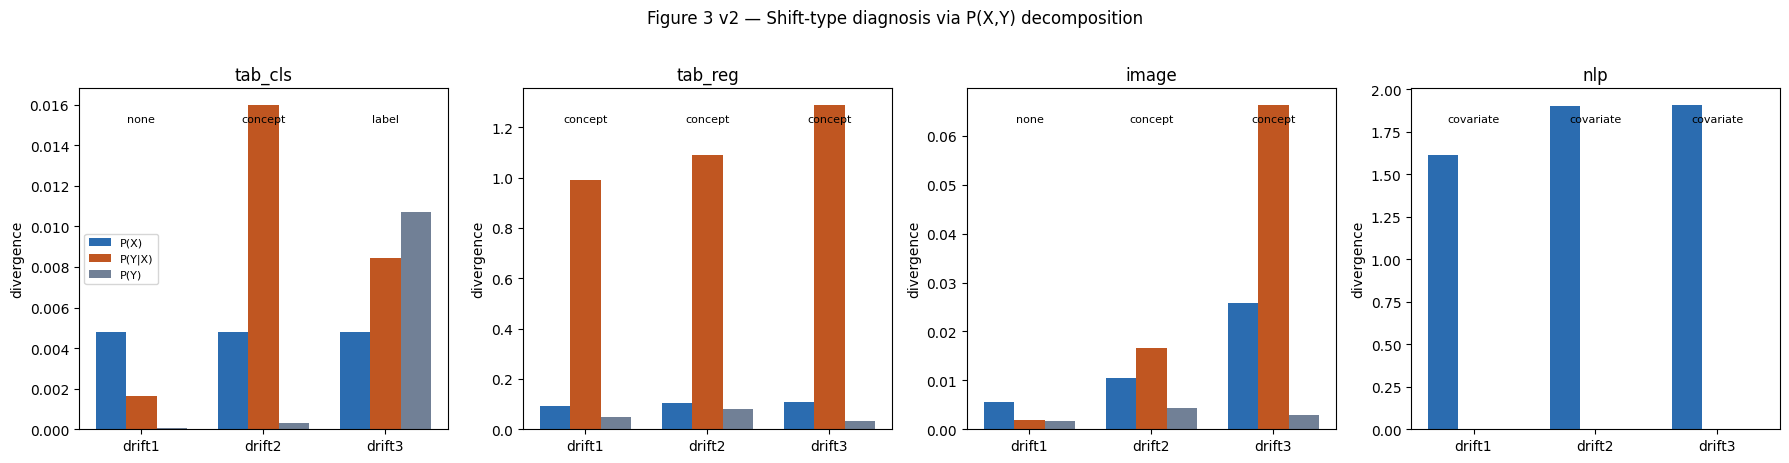

In [ ]:
df_diag=pd.DataFrame(DIAG)
fig,axes=plt.subplots(1,4,figsize=(18,4.5))
for ax,mod in zip(axes,['tab_cls','tab_reg','image','nlp']):
    sub=df_diag[df_diag.modality==mod]; x=np.arange(len(sub)); w=0.25
    ax.bar(x-w,sub['P(X)'],w,label='P(X)',color='#2B6CB0')
    ax.bar(x,sub['P(Y|X)'],w,label='P(Y|X)',color='#C05621')
    ax.bar(x+w,sub['P(Y)'],w,label='P(Y)',color='#718096')
    ax.set_xticks(x); ax.set_xticklabels(sub['drift'].values); ax.set_title(mod); ax.set_ylabel('divergence')
    for i,dx in enumerate(sub['diagnosis'].values):
        ax.text(i,ax.get_ylim()[1]*0.9,dx,ha='center',fontsize=8)
axes[0].legend(fontsize=8)
plt.suptitle('Figure 3 v2 — Shift-type diagnosis via P(X,Y) decomposition',y=1.02)
plt.tight_layout(); plt.savefig(f'{OUT}/figure3_diagnosis.png',dpi=150,bbox_inches='tight'); plt.show()
with open(f'{OUT}/all_results.json','w') as f: json.dump(ALL,f,indent=2,default=str)
zp=f'{ROOT}/robustops_export_v2.zip'
with zipfile.ZipFile(zp,'w',zipfile.ZIP_DEFLATED) as z:
    for r,_,fs in os.walk(OUT):
        for fn in fs:
            fp=os.path.join(r,fn); z.write(fp,os.path.relpath(fp,ROOT))
    for r,_,fs in os.walk(CKPT):
        for fn in fs:
            fp=os.path.join(r,fn); z.write(fp,os.path.relpath(fp,ROOT))
print('EXPORT:',zp,os.path.getsize(zp)//1024,'KB')